# Guide pour l'Appel à une API Hugging Face pour la Segmentation d'Images

Bienvenue ! Ce notebook a pour but de vous guider pas à pas dans l'utilisation de l'API d'inférence de Hugging Face pour effectuer de la segmentation d'images. La segmentation d'images consiste à attribuer une étiquette (comme "cheveux", "vêtement", "arrière-plan") à chaque pixel d'une image.

Nous allons :
1. Comprendre ce qu'est une API et comment s'y connecter.
2. Envoyer une image à un modèle de segmentation hébergé sur Hugging Face.
3. Récupérer et interpréter les résultats.
4. Visualiser les masques de segmentation.
5. Étendre cela pour traiter plusieurs images.

## 1. Configuration Initiale et Importations

Commençons par importer les bibliothèques Python nécessaires. Nous aurons besoin de :
- `os` pour interagir avec le système de fichiers (lister les images).
- `requests` pour effectuer des requêtes HTTP vers l'API.
- `PIL (Pillow)` pour manipuler les images.
- `matplotlib.pyplot` pour afficher les images et les masques.
- `numpy` pour la manipulation des tableaux (les images sont des tableaux de pixels).
- `tqdm.notebook` pour afficher une barre de progression (utile pour plusieurs images).
- `base64` et `io` pour décoder les masques renvoyés par l'API.

In [1]:
import os
import requests
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import base64
import io

In [2]:
from huggingface_hub import InferenceClient

print("Import réussi !")

Import réussi !


In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

HF_TOKEN = os.environ.get("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError(
        "La variable d'environnement HF_TOKEN n'est pas définie."
    )

headers = {
    "Authorization": f"Bearer {HF_TOKEN}"
}

### Variables de Configuration

Nous devons définir quelques variables :
- `image_dir`: Le chemin vers le dossier contenant vos images. **Assurez-vous de modifier ce chemin si nécessaire.**
- `max_images`: Le nombre maximum d'images à traiter (pour ne pas surcharger l'API ou attendre trop longtemps).
- `api_token`: Votre jeton d'API Hugging Face. **IMPORTANT : Gardez ce jeton secret !**

**Comment obtenir un token API Hugging Face ?**
1. Créez un compte sur [huggingface.co](https://huggingface.co/).
2. Allez dans votre profil -> Settings -> Access Tokens.
3. Créez un nouveau token (par exemple, avec le rôle "read").
4. Copiez ce token ici.

In [4]:
# TODO: Modifiez ces valeurs selon votre configuration
image_dir = "C:\\Users\\olivi\\le-trois\\top_influenceurs_2024\\top_influenceurs_2024\\IMG\\"  # Exemple : si vous êtes sur Colab et avez uploadé un dossier
max_images = 5 # Commençons avec peu d'images

# IMPORTANT: Remplacez "VOTRE_TOKEN_HUGGING_FACE_ICI" par votre véritable token API.
# Ne partagez jamais votre token publiquement.

api_token = HF_TOKEN

# Créons le dossier d'images s'il n'existe pas (pour l'exemple)
if not os.path.exists(image_dir):
    os.makedirs(image_dir)
    print(f"Dossier '{image_dir}' créé. Veuillez y ajouter des images .jpg ou .png.")
else:
    print(f"Dossier '{image_dir}' existant.")

if api_token == HF_TOKEN:
    print("\nATTENTION : Vous devez remplacer 'VOTRE_TOKEN_HUGGING_FACE_ICI' par votre token API personnel.")

Dossier 'C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\' existant.

ATTENTION : Vous devez remplacer 'VOTRE_TOKEN_HUGGING_FACE_ICI' par votre token API personnel.


## 2. Comprendre l'API d'Inférence Hugging Face

L'API d'inférence permet d'utiliser des modèles hébergés sur Hugging Face sans avoir à les télécharger ou à gérer l'infrastructure.

- **Modèle utilisé** : Nous allons utiliser le modèle `sayeed99/segformer_b3_clothes`, spécialisé dans la segmentation de vêtements et de parties du corps.
- **URL de l'API** : L'URL pour un modèle est généralement `https://api-inference.huggingface.co/models/NOM_DU_MODELE`.
- **Headers (En-têtes)** : Pour s'authentifier et spécifier le type de contenu, nous envoyons des en-têtes avec notre requête.
    - `Authorization`: Contient notre token API (précédé de `Bearer `).
    - `Content-Type`: Indique que nous envoyons une image au format JPEG (ou PNG selon le cas).

In [5]:
client = InferenceClient(
    token=api_token
)

print("Client Hugging Face créé !")

Client Hugging Face créé !


In [7]:
# API_URL = "https://huggingface.co/sayeed99/segformer_b3_clothes" # Remplacez ... par le bon endpoint.
headers = {
    "Authorization": f"Bearer {api_token}"
    # Le "Content-Type" sera ajouté dynamiquement lors de l'envoi de l'image
}

# Lister les chemins des images à traiter
# Assurez-vous d'avoir des images dans le dossier 'image_dir'!
#image_paths = ["C:\\Users\\olivi\\le-trois\\top_influenceurs_2024\\top_influenceurs_2024\\IMG\\image_0.png", "C:\\Users\\olivi\\le-trois\\top_influenceurs_2024\\top_influenceurs_2024\\IMG\\image_1.png", "C:\\Users\\olivi\\le-trois\\top_influenceurs_2024\\top_influenceurs_2024\\IMG\\image_2.png"] # A vous de jouer !
image_paths = [
    os.path.join(image_dir, filename)
    for filename in os.listdir(image_dir)
    if filename.startswith("image_") and filename.endswith(".png")
]

image_paths.sort(key=lambda x: int(os.path.basename(x).split("_")[1].split(".")[0]))

print(f"{len(image_paths)} image(s) à traiter")

for image_path in image_paths:
    print(f"Traitement de l'image : {image_path}")
#
single_image_path = image_paths[0]

print(f"Traitement de l'image : {single_image_path}")

try:
    # Lire l'image en binaire
    with open(single_image_path, "rb") as f:
        image_data = f.read()

    print(f"Taille de l'image : {len(image_data)} octets")

    # Appel au modèle Hugging Face
    results = client.image_segmentation(
        image_data,
        model="sayeed99/segformer_b3_clothes",
        parameters={
            "format": "png"
        }
    )
    print(f"Nombre de résultats : {len(results)}")

    # Afficher les classes retournées
    for result in results:
        print(
            f"Classe : {result.label}, "
            f"score : {result.score}"
        )

except Exception as e:
    print(f"Une erreur est survenue : {e}")

#

if not image_paths:
    print(f"Aucune image trouvée dans '{image_dir}'. Veuillez y ajouter des images.")
else:
    print(f"{len(image_paths)} image(s) à traiter : {image_paths}")

50 image(s) à traiter
Traitement de l'image : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_0.png
Traitement de l'image : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_1.png
Traitement de l'image : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_2.png
Traitement de l'image : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_3.png
Traitement de l'image : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_4.png
Traitement de l'image : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_5.png
Traitement de l'image : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_6.png
Traitement de l'image : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_7.png
Traitement de l'image : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_8.png
Traite

## 3. Fonctions Utilitaires pour le Traitement des Masques

Le modèle que nous utilisons (`sayeed99/segformer_b3_clothes`) renvoie des masques pour différentes classes (cheveux, chapeau, etc.). Ces masques sont encodés en base64. Les fonctions ci-dessous sont fournies pour vous aider à :
1.  `CLASS_MAPPING`: Un dictionnaire qui associe les noms de classes (ex: "Hat") à des identifiants numériques.
2.  `get_image_dimensions`: Récupérer les dimensions d'une image.
3.  `decode_base64_mask`: Décoder un masque de base64 en une image (tableau NumPy) et le redimensionner.
4.  `create_masks`: Combiner les masques de toutes les classes détectées en un seul masque de segmentation final, où chaque pixel a la valeur de l'ID de sa classe.

**Cette partie est donnée car elle est spécifique au format de sortie de ce modèle et un peu complexe pour une première approche.** Lisez-la pour comprendre son rôle, mais ne vous attardez pas sur les détails d'implémentation pour l'instant.

# partie mise en markdown
# plus utilisé : def decode_base64_mask(base64_string, width, height):
CLASS_MAPPING = {
    "Background": 0,
    "Hat": 1,
    "Hair": 2,
    "Sunglasses": 3,
    "Upper-clothes": 4,
    "Skirt": 5,
    "Pants": 6,
    "Dress": 7,
    "Belt": 8,
    "Left-shoe": 9,
    "Right-shoe": 10,
    "Face": 11,
    "Left-leg": 12,
    "Right-leg": 13,
    "Left-arm": 14,
    "Right-arm": 15,
    "Bag": 16,
    "Scarf": 17
}

def get_image_dimensions(img_path):
    """
    Get the dimensions of an image.

    Args:
        img_path (str): Path to the image.

    Returns:
        tuple: (width, height) of the image.
    """
    original_image = Image.open(img_path)
    return original_image.size

def decode_base64_mask(base64_string, width, height):
    """
    Decode a base64-encoded mask into a NumPy array.

    Args:
        base64_string (str): Base64-encoded mask.
        width (int): Target width.
        height (int): Target height.

    Returns:
        np.ndarray: Single-channel mask array.
    """
    mask_data = base64.b64decode(base64_string)
    mask_image = Image.open(io.BytesIO(mask_data))
    mask_array = np.array(mask_image)
    if len(mask_array.shape) == 3:
        mask_array = mask_array[:, :, 0]  # Take first channel if RGB
    mask_image = Image.fromarray(mask_array).resize((width, height), Image.NEAREST)
    return np.array(mask_image)

def create_masks(results, width, height):
    """
    Combine multiple class masks into a single segmentation mask.

    Args:
        results (list): List of dictionaries with 'label' and 'mask' keys.
        width (int): Target width.
        height (int): Target height.

    Returns:
        np.ndarray: Combined segmentation mask with class indices.
    """
    combined_mask = np.zeros((height, width), dtype=np.uint8)  # Initialize with Background (0)

    # Process non-Background masks first
    for result in results:
        label = result['label']
        class_id = CLASS_MAPPING.get(label, 0)
        if class_id == 0:  # Skip Background
            continue
        mask_array = decode_base64_mask(result['mask'], width, height)
        combined_mask[mask_array > 0] = class_id

    # Process Background last to ensure it doesn't overwrite other classes unnecessarily
    # (Though the model usually provides non-overlapping masks for distinct classes other than background)
    for result in results:
        if result['label'] == 'Background':
            mask_array = decode_base64_mask(result['mask'], width, height)
            # Apply background only where no other class has been assigned yet
            # This logic might need adjustment based on how the model defines 'Background'
            # For this model, it seems safer to just let non-background overwrite it first.
            # A simple application like this should be fine: if Background mask says pixel is BG, set it to 0.
            # However, a more robust way might be to only set to background if combined_mask is still 0 (initial value)
            combined_mask[mask_array > 0] = 0 # Class ID for Background is 0

    return combined_mask

In [8]:
CLASS_MAPPING = {
    "Background": 0,
    "Hat": 1,
    "Hair": 2,
    "Sunglasses": 3,
    "Upper-clothes": 4,
    "Skirt": 5,
    "Pants": 6,
    "Dress": 7,
    "Belt": 8,
    "Left-shoe": 9,
    "Right-shoe": 10,
    "Face": 11,
    "Left-leg": 12,
    "Right-leg": 13,
    "Left-arm": 14,
    "Right-arm": 15,
    "Bag": 16,
    "Scarf": 17
}

def get_image_dimensions(img_path):
    """
    Get the dimensions of an image.

    Args:
        img_path (str): Path to the image.

    Returns:
        tuple: (width, height) of the image.
    """
    original_image = Image.open(img_path)
    return original_image.size

def create_masks(results, width, height):
    """
    Combine les masques retournés par Hugging Face
    en un seul masque de segmentation.
    """

    combined_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    for result in results:

        # Récupération du label
        label = result.label

        # Conversion du label en identifiant numérique
        class_id = CLASS_MAPPING.get(label, 0)

        # On ignore le background
        if class_id == 0:
            continue

        # Le masque est déjà une image PIL
        mask_image = result.mask

        # Mise à la taille de l'image originale
        mask_image = mask_image.resize(
            (width, height),
            Image.NEAREST
        )

        # Conversion PIL -> NumPy
        mask_array = np.array(mask_image)

        # Application du masque
        combined_mask[mask_array > 0] = class_id

    return combined_mask

## 4. Segmentation d'une Seule Image

Avant de traiter toutes les images, concentrons-nous sur une seule pour bien comprendre le processus.

Étapes :
1.  Choisir une image.
2.  Ouvrir l'image en mode binaire (`"rb"`) et lire son contenu (`data`).
3.  Déterminer le `Content-Type` (par exemple, `"image/jpeg"` ou `"image/png"`).
4.  Envoyer la requête POST à l'API avec `requests.post()` en passant l'URL, les headers et les données.
5.  Vérifier le code de statut de la réponse. Une erreur sera levée si le code n'est pas 2xx (succès) grâce à `response.raise_for_status()`.
6.  Convertir la réponse JSON en un dictionnaire Python avec `response.json()`.
7.  Utiliser nos fonctions `get_image_dimensions` et `create_masks` pour obtenir le masque final.
8.  Afficher l'image originale et le masque segmenté.

# cellule mise en markdown, car annulée
if image_paths:
    single_image_path = image_paths[0] # Prenons la première image de notre liste
    print(f"Traitement de l'image : {single_image_path}")

    try:
        # Lire l'image en binaire
        with open(single_image_path, "rb") as f:
            image_data = f.read()

        # Appel de l'API Hugging Face
        response = requests.post(
            API_URL,
            headers=headers,
            data=image_data
        )

        # Vérifier que la requête a réussi
        if response.status_code != 200:
            print(f"Erreur API ({response.status_code}) : {response.text}")
        else:
            # Récupérer les résultats JSON
            results = response.json()

            # Récupérer les dimensions originales
            width, height = get_image_dimensions(single_image_path)

            # Créer le masque de segmentation combiné
            segmentation_mask = create_masks(
                results,
                width,
                height
            )

            print("Segmentation terminée.")
            print("Dimensions du masque :", segmentation_mask.shape)

            # Afficher l'image originale et le masque
            plt.figure(figsize=(12, 5))

            plt.subplot(1, 2, 1)
            original_image = Image.open(single_image_path)
            plt.imshow(original_image)
            plt.title("Image originale")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.imshow(segmentation_mask, cmap="tab20")
            plt.title("Masque de segmentation")
            plt.axis("off")

            plt.show()

    except Exception as e:
        print(f"Une erreur est survenue : {e}")
else:
    print("Aucune image à traiter. Vérifiez la configuration de 'image_dir' et 'max_images'.")

Traitement de l'image : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_0.png
Nombre de résultats : 11
Segmentation terminée.
Dimensions du masque : (600, 400)


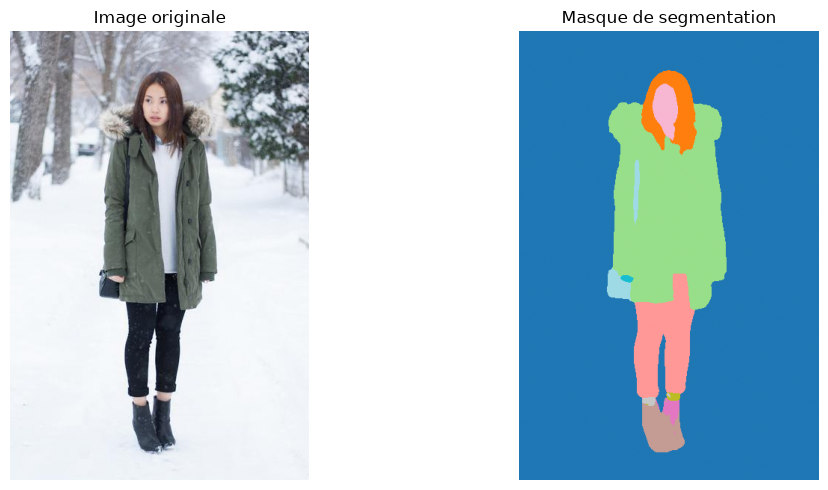

In [9]:
if image_paths:
    single_image_path = image_paths[0]
    print(f"Traitement de l'image : {single_image_path}")

    try:
        # Lire l'image en binaire
        with open(single_image_path, "rb") as f:
            image_data = f.read()

        # Appel du modèle Hugging Face avec InferenceClient
        results = client.image_segmentation(
            single_image_path,
            model="sayeed99/segformer_b3_clothes",
        )

        print(f"Nombre de résultats : {len(results)}")

        # Récupérer les dimensions originales
        width, height = get_image_dimensions(single_image_path)

        # Créer le masque de segmentation combiné
        segmentation_mask = create_masks(
            results,
            width,
            height
        )

        print("Segmentation terminée.")
        print("Dimensions du masque :", segmentation_mask.shape)

        # Afficher l'image originale et le masque
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        original_image = Image.open(single_image_path)
        plt.imshow(original_image)
        plt.title("Image originale")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(segmentation_mask, cmap="tab20")
        plt.title("Masque de segmentation")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Une erreur est survenue : {e}")

else:
    print(
        "Aucune image à traiter. "
        "Vérifiez la configuration de 'image_dir' et 'max_images'."
    )

In [10]:
import requests

url = "https://huggingface.co"

try:
    response = requests.get(url, timeout=10)
    print("Connexion réussie :", response.status_code)
except Exception as e:
    print("Erreur :", e)

Connexion réussie : 200


## 5. Segmentation de Plusieurs Images (Batch)

Maintenant que nous savons comment traiter une image, nous pouvons créer une fonction pour en traiter plusieurs.
Cette fonction va boucler sur la liste `image_paths` et appliquer la logique de segmentation à chaque image.
Nous utiliserons `tqdm` pour avoir une barre de progression.

# cellule transformée en markdown
import time

def segment_images_batch(list_of_image_paths):
    """
    Segmente une liste d'images en utilisant l'API Hugging Face.

    Args:
        list_of_image_paths (list): Liste des chemins vers les images.

    Returns:
        list: Liste des masques de segmentation (tableaux NumPy).
              Contient None si une image n'a pas pu être traitée.
    """
    for image_path in tqdm(list_of_image_paths):

        try:
            # Lire l'image en binaire
            with open(image_path, "rb") as f:
                image_data = f.read()

            # Envoyer l'image à l'API Hugging Face
            response = requests.post(
                API_URL,
                headers=headers,
                data=image_data
            )

            # Vérifier la réponse de l'API
            if response.status_code != 200:
                print(
                    f"Erreur pour {image_path} "
                    f"({response.status_code}) : {response.text}"
                )
                batch_segmentations.append(None)

            else:
                # Récupérer les résultats
                results = response.json()

                # Dimensions de l'image originale
                width, height = get_image_dimensions(image_path)

                # Créer le masque combiné
                segmentation_mask = create_masks(
                    results,
                    width,
                    height
                )

                batch_segmentations.append(segmentation_mask)

        except Exception as e:
            print(f"Erreur lors du traitement de {image_path} : {e}")
            batch_segmentations.append(None)

        # Pause entre les appels API
        time.sleep(1)

#La pause de 1 seconde est volontaire : elle évite d'enchaîner trop rapidement les requêtes vers l'API.
    return batch_segmentations

    # N'oubliez pas de mettre une pause entre chaque appel API !


# Appeler la fonction pour segmenter les images listées dans image_paths
if image_paths:
    print(f"\nTraitement de {len(image_paths)} image(s) en batch...")
    batch_seg_results = segment_images_batch(image_paths)
    print("Traitement en batch terminé.")
else:
    batch_seg_results = []
    print("Aucune image à traiter en batch.")

In [11]:
import time
from tqdm import tqdm

def segment_images_batch(list_of_image_paths):
    """
    Segmente plusieurs images avec Hugging Face.

    Returns:
        list: Liste des masques de segmentation.
              Contient None si une image n'a pas pu être traitée.
    """

    # Liste qui contiendra les résultats
    batch_segmentations = []

    # Parcours des images
    for image_path in tqdm(list_of_image_paths):

        try:
            print(f"\nTraitement de : {image_path}")

            # Segmentation avec Hugging Face
            results = client.image_segmentation(
                image_path,
                model="sayeed99/segformer_b3_clothes"
            )

            # Dimensions de l'image originale
            width, height = get_image_dimensions(image_path)

            # Création du masque combiné
            segmentation_mask = create_masks(
                results,
                width,
                height
            )

            # Ajouter le masque aux résultats
            batch_segmentations.append(segmentation_mask)

            print("Segmentation terminée.")

        except Exception as e:
            print(f"Erreur lors du traitement de {image_path} : {e}")

            # Ajouter None pour conserver la correspondance
            # entre les images et les résultats
            batch_segmentations.append(None)

        # Petite pause entre les requêtes
        time.sleep(1)

    return batch_segmentations

In [12]:
# Appeler la fonction pour segmenter les images listées dans image_paths
if image_paths:
    print(f"\nTraitement de {len(image_paths)} image(s) en batch...")
    batch_seg_results = segment_images_batch(image_paths)
    print("Traitement en batch terminé.")
else:
    batch_seg_results = []
    print("Aucune image à traiter en batch.")


Traitement de 50 image(s) en batch...


  0%|          | 0/50 [00:00<?, ?it/s]


Traitement de : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_0.png
Segmentation terminée.


  2%|▏         | 1/50 [00:01<01:29,  1.82s/it]


Traitement de : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_1.png
Segmentation terminée.


...


Traitement de : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_48.png
Segmentation terminée.


 98%|█████████▊| 49/50 [01:35<00:01,  1.87s/it]


Traitement de : C:\Users\olivi\le-trois\top_influenceurs_2024\top_influenceurs_2024\IMG\image_49.png
Segmentation terminée.


100%|██████████| 50/50 [01:37<00:00,  1.94s/it]

Traitement en batch terminé.


## 6. Affichage des Résultats en Batch

Nous allons maintenant créer une fonction pour afficher les images originales et leurs segmentations correspondantes côte à côte, dans une grille.

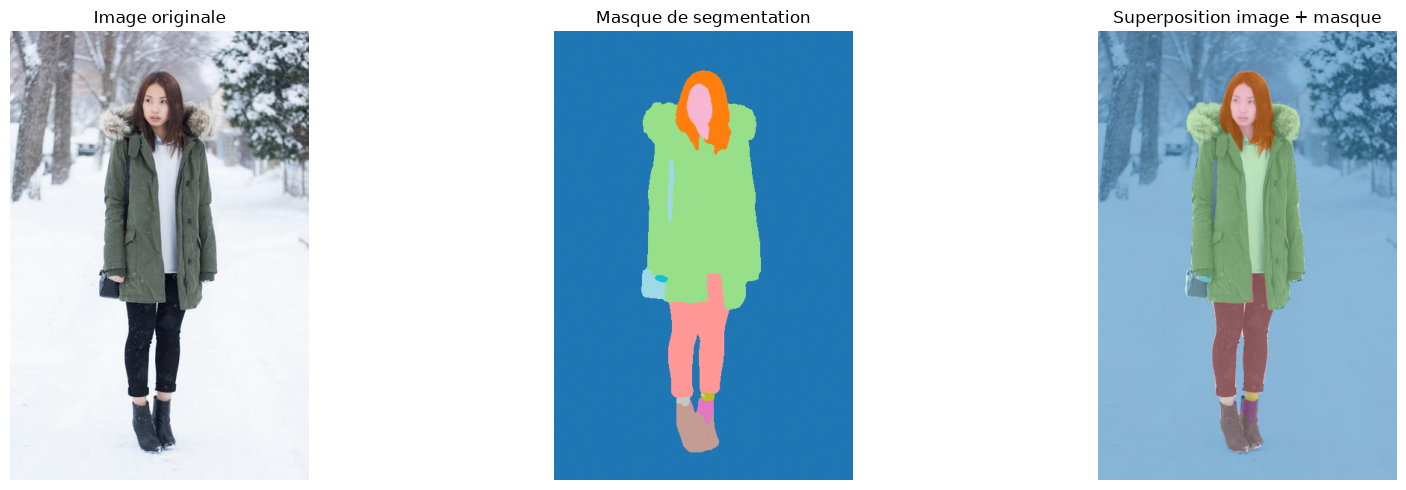

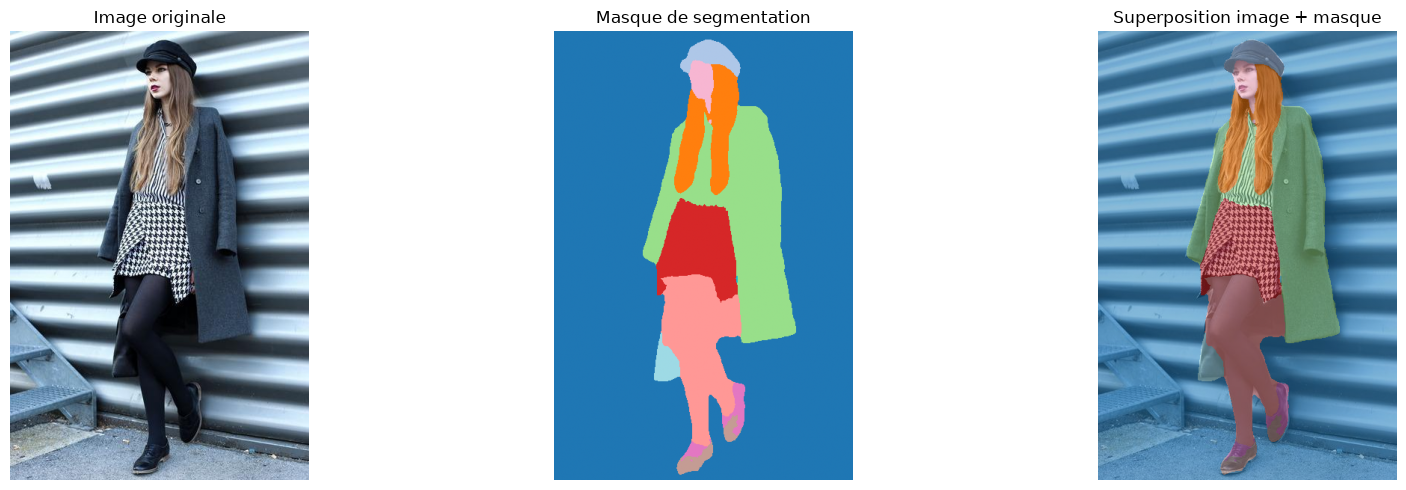

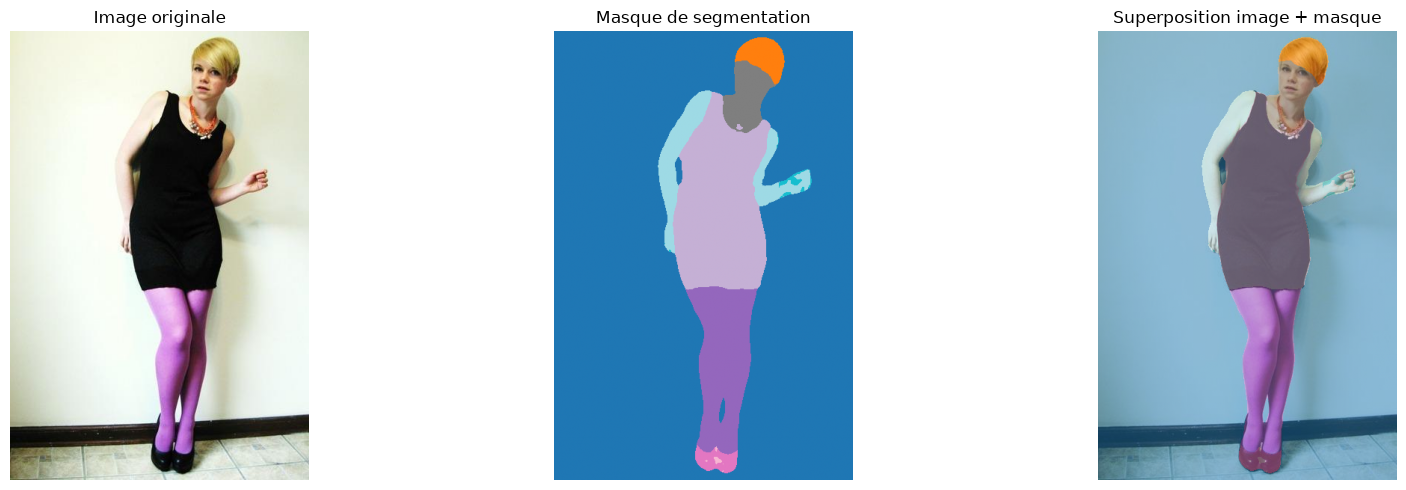

In [12]:
def display_segmented_images_batch(original_image_paths, segmentation_masks):
    """
    Affiche les images originales, les masques segmentés
    et la superposition image + masque.
    """

    for image_path, segmentation_mask in zip(
        original_image_paths,
        segmentation_masks
    ):

        # Si l'image n'a pas pu être segmentée
        if segmentation_mask is None:
            print(f"Pas de résultat pour : {image_path}")
            continue

        # Charger l'image originale
        original_image = Image.open(image_path).convert("RGB")

        # Créer une figure avec 3 images
        plt.figure(figsize=(18, 5))

        # 1. Image originale
        plt.subplot(1, 3, 1)
        plt.imshow(original_image)
        plt.title("Image originale")
        plt.axis("off")

        # 2. Masque de segmentation
        plt.subplot(1, 3, 2)
        plt.imshow(segmentation_mask, cmap="tab20")
        plt.title("Masque de segmentation")
        plt.axis("off")

        # 3. Superposition image + masque
        plt.subplot(1, 3, 3)

        # Afficher l'image originale
        plt.imshow(original_image)

        # Ajouter le masque par-dessus avec transparence
        plt.imshow(
            segmentation_mask,
            cmap="tab20",
            alpha=0.5
        )

        plt.title("Superposition image + masque")
        plt.axis("off")

        plt.tight_layout()
        plt.show()


# Afficher les résultats du batch
if batch_seg_results:
    display_segmented_images_batch(
        image_paths,
        batch_seg_results
    )
else:
    print("Aucun résultat de segmentation à afficher.")

## Conclusion et Prochaines Étapes

Félicitations ! Vous avez appris à :
- Configurer les appels à l'API d'inférence Hugging Face.
- Envoyer des images pour la segmentation.
- Interpréter les résultats (avec l'aide des fonctions fournies).
- Visualiser les segmentations.

Pistes d'amélioration ou d'exploration :
- **Gestion d'erreurs plus fine** : Implémenter des tentatives multiples (retry) en cas d'échec de l'API (par exemple, si le modèle est en cours de chargement).
- **Appels asynchrones** : Pour un grand nombre d'images, des appels asynchrones (avec `asyncio` et `aiohttp`) seraient beaucoup plus rapides.
- **Autres modèles** : Explorer d'autres modèles de segmentation ou d'autres tâches sur Hugging Face Hub.

N'hésitez pas à modifier le code, à tester avec vos propres images et à explorer davantage !

**_Note_** : Si vous aimez ce modèle, n'hésitez pas à le [télécharger](https://huggingface.co/sayeed99/segformer_b3_clothes) et jouer avec directement sur votre machine !